# Data Source for Bias Analysis

The dataset used in this bias analysis originates from the data cleaning process performed in the Data Quality notebook. After completing the cleaning and validation steps, the processed dataset was saved in Databricks as a table (cleaned_credit_applications).

This notebook reads that cleaned table and uses it as the input for the analytical stage, where potential bias in credit approval decisions is evaluated. By separating the data preparation and analysis stages, the workflow ensures a clearer pipeline and consistent use of the validated dataset.

# 1. Bias and Fairness in Credit Decision Systems

Traditional data quality checks ensure accuracy, completeness, and consistency, but they do not guarantee fairness.

Even when a dataset is technically correct, it may still reflect historical patterns of discrimination or structural inequalities.

Therefore, it is important to evaluate potential bias in the NovaCred credit application dataset. This section analyzes whether loan approval outcomes differ across demographic groups using fairness metrics and group-level approval analysis.


# 2.Analysis Overview
The analysis includes:

- Approval rate computation by gender  
- Disparate Impact (DI) ratio calculation under the 80% rule  
- Sample size validation to assess selection bias risk  
- Income distribution analysis across gender groups  
- ZIP code–based regional analysis to examine potential proxy effects  
- Interpretation of findings in relation to historical, selection, and measurement bias types  

Important note:    
Disparate Impact identifies statistical disparities rather than causality or discriminatory intent. The findings should be interpreted as a governance-level fairness screening and may require deeper multivariate analysis for regulatory-grade validation.

# 3.Setup and Load Clean Dataset

In [0]:

from pyspark.sql import functions as F

# Load cleaned dataset produced in the Data Quality notebook
df = spark.table("clean_credit_data")

df.printSchema()
display(df.limit(5))
df.printSchema()

root
 |-- _id: string (nullable = true)
 |-- gender_standardized: string (nullable = true)
 |-- dob_clean: date (nullable = true)
 |-- annual_income_clean: double (nullable = true)
 |-- zip_clean: string (nullable = true)
 |-- loan_approved: boolean (nullable = true)
 |-- debt_to_income: double (nullable = true)



_id,gender_standardized,dob_clean,annual_income_clean,zip_clean,loan_approved,debt_to_income
app_307,male,1990-07-26,53000.0,10097,true,0.1
app_133,male,1989-10-07,70000.0,10022,false,0.16
app_130,female,1981-10-03,135000.0,90252,false,0.09
app_404,male,1985-11-10,91000.0,10017,true,0.32
app_407,male,1990-11-09,74000.0,10076,false,0.26


root
 |-- _id: string (nullable = true)
 |-- gender_standardized: string (nullable = true)
 |-- dob_clean: date (nullable = true)
 |-- annual_income_clean: double (nullable = true)
 |-- zip_clean: string (nullable = true)
 |-- loan_approved: boolean (nullable = true)
 |-- debt_to_income: double (nullable = true)



This step loads the cleaned dataset generated during the Data Quality phase.
Bias analysis should be performed on remediated data to ensure that fairness metrics are not distorted by data quality issues.

# 4. Dataset Representation

Before evaluating fairness metrics, it is important to examine the representation of demographic groups in the dataset.

If one group is severely underrepresented, fairness metrics may be unreliable or misleading. Therefore, we first analyze the distribution of applicants across gender groups.

# 5. Potential Sources of Bias

Several types of bias may occur in credit decision datasets. Understanding these sources is important because biased data can lead to unfair automated decisions. Common types include historical bias, selection bias, measurement bias, aggregation bias, feedback loop bias, and proxy bias.

### Historical Bias
Historical bias occurs when past lending decisions reflect structural inequalities or discriminatory practices. If certain demographic groups historically received fewer loan approvals, these patterns may be embedded in the dataset.

### Selection Bias
Selection bias occurs when the dataset does not represent the full population of credit applicants. If some groups are underrepresented, the model may learn patterns that disadvantage those groups.

### Measurement Bias
Measurement bias arises when variables do not perfectly capture the concept they represent. For example, income or employment status may not fully reflect an applicant’s financial stability.

### Aggregation Bias
Aggregation bias occurs when the same decision model is applied to diverse groups with different characteristics, potentially leading to unequal performance across groups.

### Feedback Loop Bias
Feedback loop bias occurs when past decisions influence future data. If certain groups are repeatedly denied loans, they may appear less frequently in future datasets.

### Proxy Variables
Even when protected attributes are removed, other variables such as income level or geographic location may act as proxies for demographic characteristics, potentially leading to indirect discrimination.

# 6. Historical Bias



### Loan Approval Rate by Gender

Approval rates were computed for each gender group by dividing the number of approved applications by the total number of applications in that group.

Approval Rate = Approved Applications / Total Applications

This metric provides an initial view of group-level differences in lending outcomes and serves as the basis for evaluating potential disparities across gender groups.

In [0]:
approval_by_gender = (
    df.groupBy("gender_standardized")
      .agg(
          F.count("*").alias("total_applications"),
          F.sum(F.col("loan_approved").cast("int")).alias("approved_count")
      )
      .withColumn(
          "approval_rate",
          F.col("approved_count") / F.col("total_applications")
      )
)

display(approval_by_gender)

gender_standardized,total_applications,approved_count,approval_rate
male,247,163,0.659919028340081
female,251,127,0.5059760956175299
unknown,2,2,1.0


The "unknown" gender category contains only two observations (n=2). 
Due to this very small sample size, it was excluded from the fairness comparison.

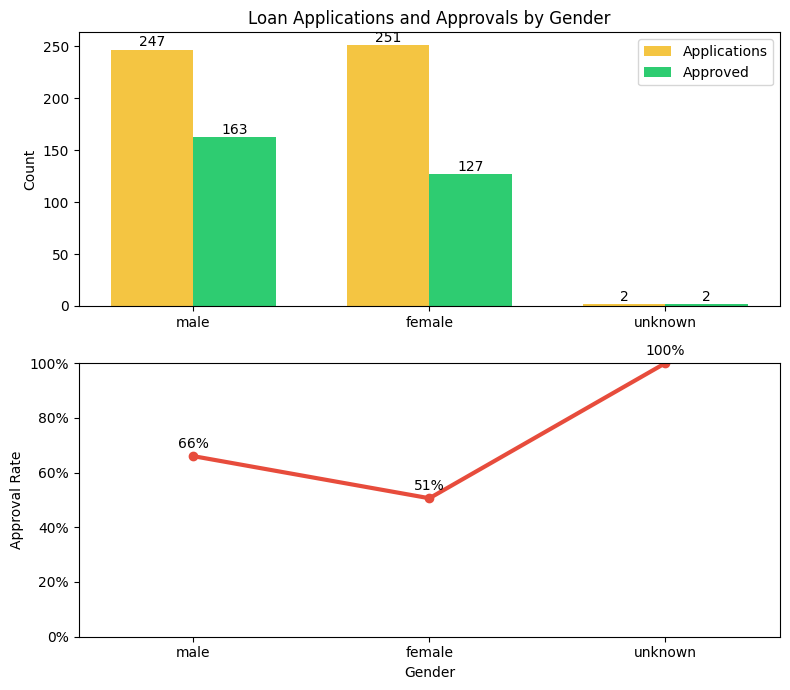

In [0]:
import matplotlib.pyplot as plt
import numpy as np

approval_pd = approval_by_gender.toPandas()

labels = approval_pd["gender_standardized"]
applications = approval_pd["total_applications"]
approved = approval_pd["approved_count"]
approval_rate = approval_pd["approval_rate"]

x = np.arange(len(labels))
width = 0.35

fig, (ax1, ax2) = plt.subplots(
    2, 1,
    figsize=(8,7),
    sharex=True
)

# Üst grafik
bars1 = ax1.bar(x - width/2, applications, width, label="Applications", color="#f4c542")
bars2 = ax1.bar(x + width/2, approved, width, label="Approved", color="#2ecc71")

ax1.set_ylabel("Count")
ax1.set_title("Loan Applications and Approvals by Gender")

ax1.set_xticks(x)
ax1.set_xticklabels(labels)
ax1.tick_params(axis="x", labelbottom=True)

ax1.legend()

for bar in bars1:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        f"{int(height)}",
        ha="center"
    )

for bar in bars2:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height + 3,
        f"{int(height)}",
        ha="center"
    )

# Alt grafik
ax2.plot(x, approval_rate, color="#e74c3c", marker="o", linewidth=3)

ax2.set_ylabel("Approval Rate")
ax2.set_xlabel("Gender")

ax2.set_xticks(x)
ax2.set_xticklabels(labels)

ax2.set_ylim(0,1)
ax2.set_yticks([0,0.2,0.4,0.6,0.8,1])
ax2.set_yticklabels(["0%","20%","40%","60%","80%","100%"])

for i, rate in enumerate(approval_rate):
    ax2.text(i, rate + 0.03, f"{rate*100:.0f}%", ha="center")

plt.tight_layout()
plt.show()


**Figure**: Loan Applications, Approvals and Approval Rate by Gender.
Male and female applicants submit a similar number of applications, but male applicants have a higher approval rate (66%) compared to female applicants (51%). The “unknown” category contains only two observations. Due to this very small sample size, the category is retained in the dataset but **soft deleted** from fairness analysis, meaning it is excluded from comparative evaluation while still being preserved for transparency.

## Interpretation

The results show a noticeable difference in approval rates across gender groups. Male applicants have an approval rate of approximately 0.66, while female applicants have an approval rate of around 0.51.

This gap indicates that female applicants are approved less frequently than male applicants in the dataset.

Although both gender groups are similarly represented in the applicant pool, the difference in approval rates suggests a potential disparity in lending outcomes. This observation motivates further fairness analysis using the Disparate Impact metric to evaluate whether the disparity exceeds commonly used fairness thresholds.

The dataset also contains a very small number of records with an "unknown" gender category (n=2). Because this group represents less than 1% of the dataset, it is not used for fairness comparison and is therefore excluded from the interpretation of gender disparities.

# 7. Selection Bias

Selection bias occurs when the dataset does not adequately represent the full population of interest. If certain demographic groups are underrepresented, statistical patterns learned from the data may not generalize fairly across groups.

To evaluate potential selection bias, we examine the distribution of applicants across gender groups.

## Sample Size Validation

In [0]:

approval_by_gender.select(
    "gender_standardized",
    "total_applications"
).display()

gender_standardized,total_applications
male,247
female,251
unknown,2


### Interpretation

The dataset shows a nearly balanced representation of male and female applicants, with 247 male and 251 female records. 

This balanced distribution reduces the risk that fairness metrics are distorted by severe class imbalance. However, a small number of records appear with an "unknown" gender category, which may require additional consideration in downstream analyses.

### Note on the "Unknown" Gender Category

Two records in the dataset contain an "unknown" gender value. Because this group represents less than 1% of the dataset, it is too small to compute reliable fairness metrics.

For this reason, fairness comparisons in this analysis focus on the male and female groups, while the records with unknown gender are retained in the dataset but not treated as a separate comparison group.


Before computing Disparate Impact, we verify that each group has sufficient observations.

Very small sample sizes may distort fairness metrics and produce unstable DI ratios.

# 8. Disparate Impact (DI) Analysis (80% Rule)

Disparate Impact is calculated as:

**DI = Approval Rate (Protected Group) / Approval Rate (Reference Group)**

In this analysis, **female applicants** are treated as the protected group and **male applicants** as the reference group.

**DI = Approval Rate (Female) / Approval Rate (Male)**

According to the 80% rule:

- If DI ≥ 0.80 → No statistical evidence of adverse impact  
- If DI < 0.80 → Potential adverse impact exists  

The 80% threshold is commonly used for fairness screening in practice.

In [0]:
rates = approval_by_gender.collect()

rate_dict = {
    row["gender_standardized"]: row["approval_rate"]
    for row in rates
}

male_rate = rate_dict.get("male")
female_rate = rate_dict.get("female")

di_ratio = female_rate / male_rate if male_rate else None

print("Male approval rate:", male_rate)
print("Female approval rate:", female_rate)
print("Disparate Impact Ratio (female / male):", di_ratio)

Male approval rate: 0.659919028340081
Female approval rate: 0.5059760956175299
Disparate Impact Ratio (female / male): 0.7667245129909809


## Interpretation of Computed DI

The computed approval rates show a noticeable difference between gender groups. The **male approval rate is approximately 0.66**, while the **female approval rate is approximately 0.51**, indicating that female applicants are approved less frequently than male applicants in the dataset.

Using these values, the **Disparate Impact (DI) ratio is approximately 0.77**, calculated as the approval rate of the protected group (female) divided by the approval rate of the reference group (male).

According to the **80% rule**, a DI value below 0.80 suggests the presence of **potential adverse impact**. Since the computed DI ratio (≈0.77) is below this threshold, the results indicate a **potential disparity in loan approval outcomes affecting female applicants**.

While this metric does not prove intentional discrimination, it highlights a statistically significant difference that may reflect underlying structural or historical biases and therefore warrants further investigation.

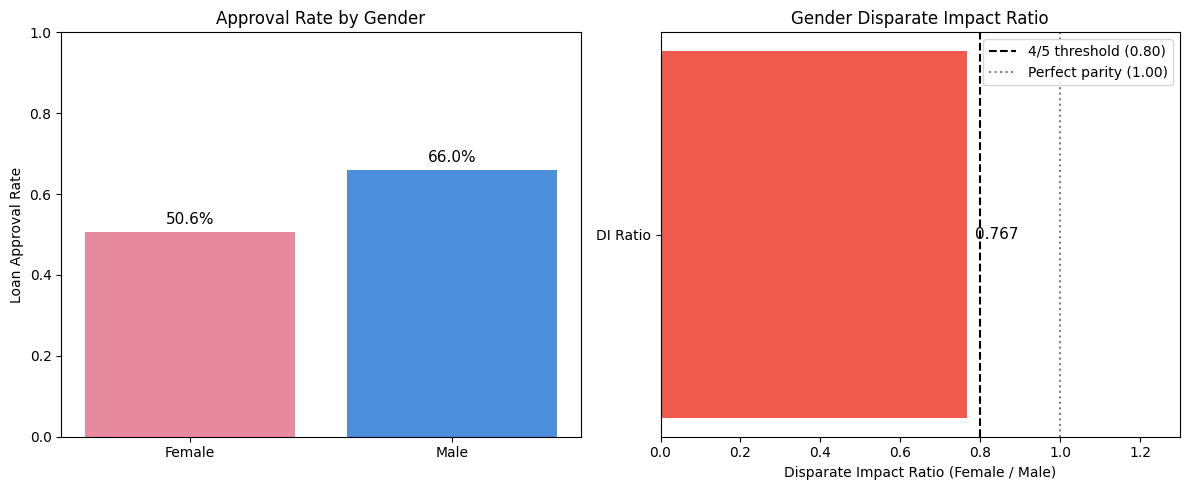

In [0]:
import matplotlib.pyplot as plt

approval_pd = approval_by_gender.toPandas()
approval_pd = approval_pd[approval_pd["gender_standardized"].isin(["male","female"])]

male_rate = approval_pd[approval_pd["gender_standardized"]=="male"]["approval_rate"].values[0]
female_rate = approval_pd[approval_pd["gender_standardized"]=="female"]["approval_rate"].values[0]

di_ratio = female_rate / male_rate

fig, axes = plt.subplots(1,2, figsize=(12,5))

# --- Approval rate plot
axes[0].bar(
    ["Female","Male"],
    [female_rate, male_rate],
    color=["#e78aa0", "#4c8ed9"]   # pink and blue
)

axes[0].set_ylim(0,1)
axes[0].set_ylabel("Loan Approval Rate")
axes[0].set_title("Approval Rate by Gender")

axes[0].text(0, female_rate + 0.02, f"{female_rate*100:.1f}%", ha='center', fontsize=11)
axes[0].text(1, male_rate + 0.02, f"{male_rate*100:.1f}%", ha='center', fontsize=11)

# --- DI ratio plot
axes[1].barh(["DI Ratio"], [di_ratio], color="#f05a4f")

axes[1].axvline(0.8, linestyle="--", color="black", label="4/5 threshold (0.80)")
axes[1].axvline(1.0, linestyle=":", color="gray", label="Perfect parity (1.00)")

axes[1].set_xlim(0,1.3)
axes[1].set_xlabel("Disparate Impact Ratio (Female / Male)")
axes[1].set_title("Gender Disparate Impact Ratio")

axes[1].text(di_ratio + 0.02, 0, f"{di_ratio:.3f}", va='center', fontsize=11)

axes[1].legend()

plt.tight_layout()
plt.show()

**Figure**: Approval Rate by Gender and Disparate Impact Ratio. Male applicants have a higher approval rate (66%) than female applicants (50.6%). The resulting Disparate Impact ratio is 0.767, which falls below the commonly used 0.80 fairness threshold.

In [0]:

if di_ratio is None:
    print("DI ratio could not be computed due to missing reference group rate.")
elif di_ratio < 0.8:
    print("⚠ Potential adverse impact detected under the 80% rule (DI < 0.80).")
elif di_ratio <= 1.25:
    print("✓ No strong evidence of adverse impact under the 80% rule (0.80 ≤ DI ≤ 1.25).")
else:
    print("⚠ DI > 1.25, possible reverse disparity signal. Further investigation recommended.")

⚠ Potential adverse impact detected under the 80% rule (DI < 0.80).


## Automated Fairness Decision Logic

To operationalize the 80% rule, we implement an automated interpretation of the Disparate Impact (DI) ratio.

This logic programmatically evaluates whether the computed DI value indicates potential adverse impact, no strong evidence of disparity, or possible reverse disparity.

Automating this step improves reproducibility and ensures consistent fairness screening across datasets.


## Statistical Interpretation Note


Disparate Impact identifies proportional differences between groups, not causality.

Observed disparity may result from:
- Legitimate financial risk variables
- Data imbalance
- Feature interactions
- Historical structural patterns

A regulatory-grade fairness audit would require multivariate modeling, controlled testing, or counterfactual analysis.

# 9. Measurement Bias



## Proxy Variable Investigation for Measurement Bias

## -Income Level by Gender

In [0]:
from pyspark.sql import functions as F

income_by_gender = (
    df.groupBy("gender_standardized")
      .agg(
          F.avg("annual_income_clean").alias("avg_income"),
          F.expr("percentile_approx(annual_income_clean, 0.5)").alias("median_income"),
          F.stddev("annual_income_clean").alias("std_income"),
          F.count("*").alias("count")
      )
)

display(income_by_gender)

gender_standardized,avg_income,median_income,std_income,count
male,81437.24696356275,81000.0,27475.24956631777,247
female,83866.26609212351,82000.0,28522.872492817678,251
unknown,86500.0,61000.0,36062.44584051392,2


/home/spark-2d148bff-717d-4497-8c46-2b/.ipykernel/2676/command-5541379838441838-1509740286:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


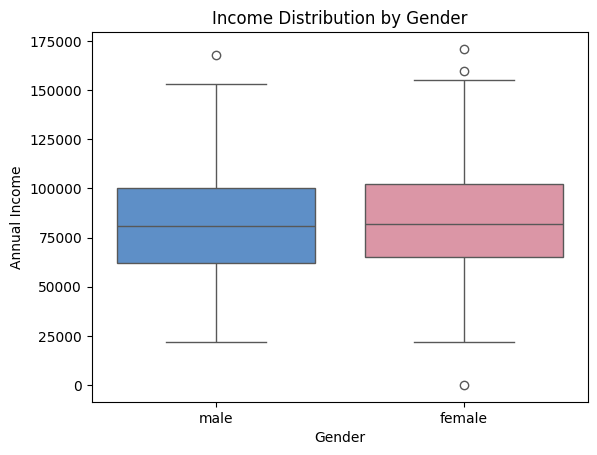

In [0]:
import seaborn as sns
import matplotlib.pyplot as plt

income_pd = df.select("gender_standardized", "annual_income_clean").toPandas()
income_pd = income_pd[income_pd["gender_standardized"].isin(["male", "female"])]

sns.boxplot(
    x="gender_standardized",
    y="annual_income_clean",
    data=income_pd,
    order=["male", "female"],
    palette={
        "male": "#4c8ed9",
        "female": "#e78aa0"
    }
)

plt.title("Income Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Annual Income")

plt.show()

The boxplot shows that the income distributions for male and female applicants are broadly similar. The median income levels are nearly identical, and the interquartile ranges overlap substantially. Although a few high income outliers appear in both groups, these observations do not indicate a systematic difference in income between genders.

## Interpretation

The income distribution appears relatively similar across gender groups. 
Male applicants have an average income of approximately 81,437 and a median income of 81,000, while female applicants show a slightly higher average income of about 83,866 and a median income of 82,000. The standard deviations are also comparable across groups, indicating similar income variability.

Because the average and median income levels are closely aligned between male and female applicants, income does not appear to differ systematically by gender in this dataset. Therefore, income is unlikely to function as a strong proxy variable for gender.

The "unknown" category contains only two observations, making it too small to draw meaningful conclusions. Overall, the results suggest that income is unlikely to introduce indirect gender related bias through proxy effects in the current dataset.

## -ZIP Code / Region by Gender

In [0]:
from pyspark.sql import functions as F

df = df.withColumn(
    "zip_prefix",
    F.substring(F.col("zip_clean").cast("string"), 1, 3)
)

In [0]:
zip_prefix_df = (
    df.select(
        F.substring(F.col("zip_clean").cast("string"), 1, 3).alias("zip_prefix")
    )
    .distinct()
    .orderBy("zip_prefix")
)

display(zip_prefix_df)

zip_prefix
null
100
300
902


The dataset includes applications from three ZIP code prefixes: 100 (New York City, NY), 300 (Atlanta metropolitan area, GA), and 902 (Southern California, CA). This indicates that the data represents three major metropolitan regions rather than nationwide coverage

In [0]:
approval_by_zip_prefix = (
    df.groupBy("zip_prefix")
      .agg(
          F.count("*").alias("total"),
          F.sum(F.col("loan_approved").cast("int")).alias("approved")
      )
      .withColumn("approval_rate", F.col("approved") / F.col("total"))
)

display(approval_by_zip_prefix.orderBy(F.desc("total")))

zip_prefix,total,approved,approval_rate
100,251,162,0.6454183266932271
902,230,119,0.5173913043478261
300,18,10,0.5555555555555556
null,1,1,1.0


The analysis shows moderate variation in approval rates across ZIP code prefixes. However, the differences are not large enough to clearly indicate that ZIP code functions as a proxy variable. Therefore, while geographic location may potentially act as a proxy for demographic characteristics, the current dataset does not provide strong evidence of proxy based bias.

# 10.Limitations of the Analysis
## -  Aggregation Bias
Aggregation bias was not evaluated because the dataset does not include **model predictions** or **performance metrics** across groups. Without model outputs, it is not possible to assess whether a single model performs differently for different subpopulations.

## - Feedback Loop
Aggregation bias and feedback loop effects were not evaluated because the dataset does not include **model predictions**, **performance metrics**, or **temporal information** required to analyze these forms of bias.


##Final Bias Assessment Conclusion

This analysis examined several potential sources of bias in the credit application dataset, including **historical bias**, **selection bias**, **measurement bias**, **aggregation bias**, and **feedback loop bias**.

The results reveal a measurable disparity in loan approval outcomes between gender groups. The **Disparate Impact ratio (Female / Male) falls below the 0.80** threshold defined by the four-fifths rule, indicating a **potential adverse impact against female** applicants.

This disparity does **not** appear to be driven by **representation imbalance**, as male and female applicants are **similarly distributed** within the dataset. Therefore, the **observed difference** in approval outcomes is **unlikely** to result from simple **sampling imbalance**.

The income analysis shows comparable average and median income levels across gender groups, suggesting that **income** differences alone do **not** explain the **observed approval gap**. This indicates that income is **unlikely** to function as **a strong proxy variable** for gender in the current dataset.

The geographic analysis indicates that applications are concentrated within **three metropolitan** ZIP code prefixes (100, 300, 902). Although **approval rates vary moderately** across these regions, geographic distribution alone does **not provide clear evidence of systematic bias**. However, ZIP code may still act as a **potential proxy** for socioeconomic characteristics, which could indirectly influence decision outcomes.

The persistence of approval differences despite similar representation and comparable income levels suggests that other structural or historical factors may contribute to the observed disparity in loan approval outcomes.

Some bias types could not be directly evaluated using the available data. **Aggregation bias** typically requires **model predictions** and **performance metrics** across groups in order to assess whether a single model performs differently for different subpopulations. These elements are not present in the dataset. Similarly, **feedback loop bias** generally requires **temporal information** to examine how past model decisions influence future training data. Because the dataset represents a static snapshot rather than a time-based dataset, feedback loop effects could not be analyzed.

Overall, the analysis highlights the **presence of potential fairness** risks in the loan approval outcomes. However, the current findings represent statistical disparities rather than causal relationships. A more comprehensive fairness assessment would require multivariate modeling and risk-adjusted evaluation of lending decisions, as well as access to model predictions and longitudinal data.